# XR Literature Search: AGU Abstracts
This notebook is for visualizing XR topics in AGU journals based on a Scopus search that Kristina ran.  

## Step 1: Prepare the data

Here's the Scopus query Kristina wrote: `( TITLE-ABS-KEY ( "virtual reality" ) OR TITLE-ABS-KEY ( "augmented reality" ) OR TITLE-ABS-KEY ( "virtual environment" ) OR TITLE-ABS-KEY ( "spatial computing" ) OR TITLE-ABS-KEY ( "extended reality" ) AND DOI ( 10.1029/* ) )`

We will rerun this and then inspect it.

## Read bibliography into pandas dataframe
I saved the results to a .bib file. We can use this cell to read it into a pandas dataframe for our plots.

In [9]:
import pandas as pd
import bibtexparser
import matplotlib.pyplot as plt
import numpy as np 
import os
import ads
from pathlib import Path

folder = Path('/your/path/')
infile = folder/'references.bib'
outfile = folder/'AGU_abstracts.csv'

In [4]:
# Read the .bib file
with open(infile, 'r') as bibtex_file:
    bib_database = bibtexparser.load(bibtex_file)
# Convert to DataFrame
df = pd.DataFrame(bib_database.entries)
# Data handling:
df['Year'] = pd.to_numeric(df['year']) # Cast to numeric 
print(df.shape)
df.columns

(223, 15)


Index(['adsnote', 'adsurl', 'pages', 'eid', 'month', 'volume', 'series',
       'year', 'booktitle', 'keywords', 'title', 'author', 'ENTRYTYPE', 'ID',
       'Year'],
      dtype='object')

In [6]:
df_sub=df[["year","keywords","title","author"]] 
df_sub.to_csv(outfile)

### Re-open
Cleaned up the data after combing through abstracts. AGU_abstracts.xlsx has a QC column and a notes column

In [7]:
infile = folder/'UPLOAD_AGU_abstracts.xlsx'

In [8]:
dfc=pd.read_excel(infile)
dfc=dfc.rename(columns = {'QC_check (1 if NOT relevant, 0 if relevant, 2 if complicated)': 'Abs_in'})

In [4]:
#filter out flagged entries

mask_zero = (dfc["Abs_in"] == 0)
mask_nan = (dfc['Abs_in'].isna())
mask_zero_or_nan = mask_zero | mask_nan

# Keep only the rows that satisfy the condition
df_filtered = dfc[mask_zero_or_nan]
df_filtered.shape
df_filtered

,Unnamed: 0,year,keywords,title,author,QC_flag (1 if needs checking),Abs_in,notes
0,0,2019,"0850 Geoscience education research, EDUCATION,...",{Applications of Mixed and Virtual Reality Tec...,"{Onsel}, E. and {Chang}, O. and {Mysiorek}, J....",NaN,NaN,NaN
1,1,2022,NaN,{AntARctica: An Immersive 3D Look into Antarct...,"{Boghosian}, Alexandra and {Cordero}, S. Isabe...",NaN,NaN,NaN
2,2,2020,9820 Techniques applicable in three or more fi...,{JMARS Augmented and Virtual Reality Experienc...,"{Gold}, L. and {Bartolomea}, H. and {Xiong}, S...",NaN,NaN,NaN
3,3,2017,"1916 Data and information discovery, INFORMATI...",{Immersive Earth Science: Data Visualization i...,"{Skolnik}, S. and {Ramirez-Linan}, R.",NaN,NaN,NaN
4,4,2023,NaN,{Immersive Hydrodynamic Model for Flood Simula...,"{Hwang}, Sooncheol and {Son}, Sangyoung",NaN,NaN,NaN
...,...,...,...,...,...,...,...,...
214,214,2004,6605 Education,{Spatial Visualization in Introductory Geology...,"{Reynolds}, S.~J.",1.0,0.0,NaN
218,218,2019,"0805 Elementary and secondary education, EDUCA...",{Innovative Technologies in Teaching and Learn...,"{Bernardes}, S. and {Howard}, A. and {Mendki},...",1.0,0.0,NaN
220,220,2005,"0805 Elementary and secondary education, 0810 ...",{Improving Geoscience Outreach Through Multime...,"{Hyatt}, J.~A. and {Coron}, C.~R. and {Schroed...",1.0,0.0,Someone else check
221,221,2015,"0815 Informal education, EDUCATION, 0825 Teach...",{Novel Web-based Education Platforms for Infor...,"{Demir}, I.",NaN,NaN,NaN


In [30]:
# prepare counts to plot

xr_count = df_filtered.groupby(['year']).size().reset_index(name='count')
xr_count

,year,count
0,2001,1
1,2002,1
2,2004,3
3,2005,3
4,2006,3
5,2007,2
6,2008,3
7,2009,3
8,2010,1
9,2011,3


<BarContainer object of 21 artists>

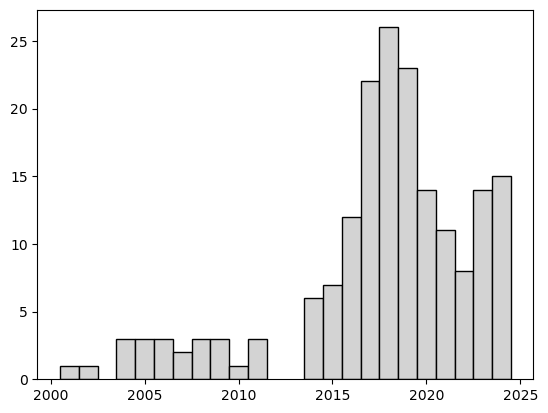

In [35]:
fig=plt.subplots()
plt.bar(xr_count['year'],xr_count['count'], width = 1,
       edgecolor='black', facecolor='lightgray')

## Get the total AGU abstracts data

Note that you will need your own token.

Now we want to also plot the total number of AGU abstracts submitted over the same period (hopefully will show a drop from 20201-2023)

In [7]:
# Get an ADS key
# import the requests package and set your token in a variable for later use
import requests
from urllib.parse import urlencode, quote_plus
token="YOUR_TOKEN"

# accented letters, special characters, and spaces need to be encoded
query = {"q": "bibcode:AGUFM"}

encoded_query = urlencode(query)
print(encoded_query)

q=bibcode%3AAGUFM


In [10]:
# Get the counts with facets!

encoded_query = urlencode({"q": 'bibstem:"AGUFM" year:2000- doctype:abstract',
                         "rows": 0,
                        "facet":"true",
                         "facet.field":"year",
                        "facet.limit":50})

results = requests.get("https://api.adsabs.harvard.edu/v1/search/query?{}",
                       headers={'Authorization': 'Bearer ' + token},
                      params=encoded_query,)
j=results.json()
j

{'responseHeader': {'status': 0,
  'QTime': 204,
  'params': {'q': 'bibstem:"AGUFM" year:2000- doctype:abstract',
   'facet.limit': '50',
   '{}': '',
   'facet.field': 'year',
   'fl': 'id',
   'start': '0',
   'internal_logging_params': 'X-Amzn-Trace-Id=Root=1-698f42b3-6c6028e41a72ca3109220bbc',
   'rows': '0',
   'facet': 'true',
   'wt': 'json'}},
 'response': {'numFound': 438424,
  'start': 0,
  'numFoundExact': True,
  'docs': []},
 'facet_counts': {'facet_queries': {},
  'facet_fields': {'year': ['2019',
    27014,
    '2018',
    26247,
    '2024',
    25946,
    '2014',
    23334,
    '2015',
    23057,
    '2016',
    22816,
    '2023',
    22550,
    '2017',
    22300,
    '2012',
    21498,
    '2013',
    21277,
    '2021',
    20672,
    '2011',
    20104,
    '2020',
    19845,
    '2022',
    19446,
    '2010',
    17923,
    '2009',
    15814,
    '2008',
    15728,
    '2007',
    13641,
    '2006',
    12988,
    '2005',
    11120,
    '2004',
    10074,
    '2003',


In [60]:
# get it out of the json format into a dataframe
pairs = list(zip(j["facet_counts"]["facet_fields"]["year"][0::2],
                 j["facet_counts"]["facet_fields"]["year"][1::2]))
df = pd.DataFrame(pairs, columns=["year", "count"])

df_tot = pd.DataFrame( {"year":df["year"].astype(int), "count":df["count"].astype(int)} )

df_tot=df_tot[ (df_tot["year"]>=2000) & (df_tot["year"]<2025 ) ]
df_tot=df_tot.sort_values("year")
df_tot

,year,count
24,2000,5
23,2001,7857
22,2002,8122
21,2003,9044
20,2004,10074
19,2005,11120
18,2006,12988
17,2007,13641
16,2008,15728
15,2009,15814


## Step 1: Make the plot

Kristina made a nice interactive plot.  The one I present here shows less detail in terms of the abstracts (which the editor may like, in order to de-emphasize AGU and broaden the audience), but also may be better suited for print. This also shows the decline in XR abstracts follows a decline in total abstracts, supporting the hypothesis that Covid was the driver.


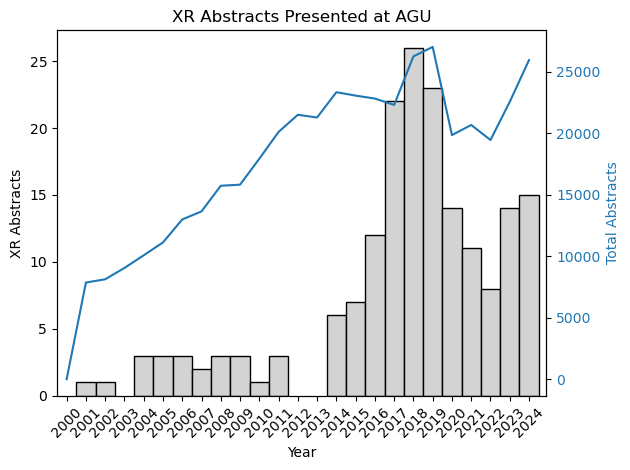

In [69]:
#plot!

fig, ax1 = plt.subplots()

#set axes
ax1.set_title("XR Abstracts Presented at AGU")
ax1.set_xlabel('Year')
ax1.set_ylabel('XR Abstracts')
ax1.set_xticks(np.linspace(2000,2025,26))
ax1.set_xlim([1999.5,2024.9])
ax1.tick_params(axis='x',rotation=45)

# XR data
ax1.bar(
    xr_count['year'],
    xr_count['count'],
    width=1,
    edgecolor='black',
    color='lightgray'
)

#add second y axis
ax2 = ax1.twinx()
ax2.set_ylabel("Total Abstracts",color="tab:blue")
ax2.tick_params(axis="y",labelcolor="tab:blue")

# total Abstracts data
ax2.plot(df_tot['year'],df_tot['count'],color="tab:blue")


fig.tight_layout()  # otherwise the right y-label is slightly clipped
plt.show()